In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("abt_churn.csv")

In [3]:
df.head()

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
0,2024-06-01,000ff655-fa9f-4baa-a108-47f581ec52a1,266,27,9.851852,635,2635,-2000,1.0,89.0,...,151,151,0,3.889781,3.278281,2.135602,1.516314,4.101926,8.944444,1
1,2024-10-01,000ff655-fa9f-4baa-a108-47f581ec52a1,268,28,9.571429,686,2686,-2000,4.0,211.0,...,51,51,0,3.309865,2.567615,2.328737,1.288278,2.920954,5.167037,1
2,2024-04-01,000ff655-fa9f-4baa-a108-47f581ec52a1,188,11,17.090909,275,1275,-1000,3.0,28.0,...,275,1275,-1000,3.805468,1.820201,3.739048,0.798622,2.634551,7.162791,0
3,2024-05-01,000ff655-fa9f-4baa-a108-47f581ec52a1,262,24,10.916667,484,2484,-2000,2.0,58.0,...,107,1107,-1000,4.246216,3.255244,2.322640,1.275749,4.275765,9.922414,0
4,2024-08-01,001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1.000000,50,50,0,21.0,21.0,...,50,50,0,0.013317,0.103973,0.236635,0.104533,0.063302,0.000000,1


## 1. S - Sample (Amostragem)
O primeiro passo é garantir que o modelo seja treinado e validado em amostras
justas e representativas, evitando o vazamento de dados (data leakage) e
garantindo a estabilidade temporal.
- Out-of-Time (OOT): Separe a safra de dados mais recente (o último mês
disponível na base) e reserve-a. Essa base não deve ser tocada até o final
do projeto; ela servirá para testar a estabilidade do modelo no tempo.
- Train/Test Split: Com o restante dos dados, faça a divisão clássica entre
base de Treino (ex: 80%) e base de Teste (ex: 20%).
- Estratificação: Ao fazer o split, garanta que a proporção da variável
resposta (flag de Churn) seja idêntica tanto no Treino quanto no Teste.

In [4]:
# Analisando ocorrências das datas
df["dtRef"].value_counts().sort_index(ascending=False)

dtRef
2025-04-01    303
2025-03-01    451
2025-02-01    374
2025-01-01    194
2024-12-01    198
2024-11-01    258
2024-10-01    349
2024-09-01    371
2024-08-01    415
2024-07-01    422
2024-06-01    426
2024-05-01    542
2024-04-01    528
2024-03-01    665
Name: count, dtype: int64

Não há nenhum registro que ocorreu fora do primeiro dia de cada mês, sendo possível apenas isolar os registros da data "2025-04-01"

In [5]:
# Isolando o último mês mais recente disponível na base
df_oot = df[df["dtRef"] == "2025-04-01"].copy().drop(columns=["dtRef", "idUsuario"])
df_model = df[df["dtRef"] != "2025-04-01"].copy().drop(columns=["dtRef", "idUsuario"])

# Divisão de variáveis (Features vs Target)
X = df_model.drop(columns=["flagChurn"])
y = df_model["flagChurn"]

from sklearn.model_selection import train_test_split

# Split com Estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 2. E - Explore (Exploração)
Antes de modificar os dados, é necessário conhecê-los intimamente. O
objetivo é identificar quais variáveis têm maior potencial para explicar o
Churn. Sendo toda a exploração feita apenas na base de treino.

- Verificação de Qualidade: Identifique se existem valores nulos (missings)
na base. Se existirem, proponha uma estratégia de tratamento sem vazar
dados da variável resposta.
- Análise Bivariada: Compare o comportamento das variáveis explicativas
(médias, medianas) separando os grupos entre quem "Deu Churn" (1) e
quem "Não Deu Churn" (0).
- Feature Importance Inicial: Ajuste uma Árvore de Decisão simples
utilizando todas as variáveis contra a variável target. Extraia a importância
das variáveis (feature importance) para ranquear quais colunas parecem
ser mais promissoras.

### Verificação de qualidade

In [6]:
# Verificando Features, colunas com valores nulos e sua quantidade
colunas_nan_X = X_train.isnull().sum()
colunas_nan_X = colunas_nan_X[colunas_nan_X > 0]
print(colunas_nan_X)

Series([], dtype: int64)


In [7]:
# Verificando Target, quantidade de nulos
colunas_nan_y = y_train.isnull().sum()
colunas_nan_y = colunas_nan_y[colunas_nan_y > 0]
print(colunas_nan_y)

[]


Não há nenhum valor nulo na base de treino, não sendo necessário tratamento

### Análise Bivariada

In [8]:
# Análise Bivariada: distanciamento estátistico - Média e Mediana

df_analise = X_train.copy()
df_analise["target"] = y_train

media = df_analise.groupby("target").mean(numeric_only=True).T
mediana = df_analise.groupby("target").median(numeric_only=True).T

media.columns = ["Não deu Churn", "Deu Churn"]
mediana.columns = ["Não deu Churn", "Deu Churn"]

comparacao = pd.concat(
    [media, mediana],
    axis=1,
    keys=["Média", "Mediana"]
)

comparacao

Média                   Mediana            
                           Não deu Churn   Deu Churn Não deu Churn   Deu Churn
qtdeTransacoes                326.906618   50.051335     52.000000    8.000000
qtdeDias                       29.777879    9.129877     13.000000    3.000000
mediaTransacoesDias             6.380571    3.927910      3.557778    2.083916
saldoPontos                  1451.726201  439.316735    563.000000  123.000000
qtdePontosPos                3073.557117  648.484600    705.000000  126.500000
qtdePontosNeg               -1621.830916 -209.167864      0.000000    0.000000
qtdeDiasUltimaTransacao         6.687670   13.425051      4.000000   14.000000
qtdeDiasPrimeiraTransacao      98.655938   72.504620     63.000000   30.000000
qtdSkuDistintos                 3.610154    2.178645      3.000000    2.000000
qtdeChatMessage               288.233001   40.677105     34.000000    5.000000
qtdePresença                   26.231188    7.726386     10.000000    2.000000
qtdeTrocaStreamElements         1.480054    0.180185      0.000000    0.000000
qtdeChurn                       5.716682    0.622177      0.000000    0.000000
qtdePonei                       1.914325    0.323922      0.000000    0.000000
qtdeAirflowLover                0.126020    0.014887      0.000000    0.000000
qtdePresencaStreak              2.061197    0.310575      0.000000    0.000000
qtdeDailyLoot                   0.782412    0.124230      0.000000    0.000000
qtdeRLover                      0.067090    0.006160      0.000000    0.000000
qtdeVendaItemRPG                0.290571    0.065195      0.000000    0.000000
qtdeTransacoesD7               14.084769    1.754620      3.000000    0.000000
qtdeDiasD7                      1.834995    0.391684      1.000000    0.000000
saldoPontosD7                  91.972801   14.834189     50.000000    0.000000
qtdePontosPosD7               159.402539   18.478953     52.000000    0.000000
qtdePontosNegD7               -67.429737   -3.644764      0.000000    0.000000
qtdeTransacoesD14              27.636446    3.598563      6.000000    1.000000
qtdeDiasD14                     3.505440    0.833676      3.000000    1.000000
saldoPontosD14                179.610154   31.100616    100.000000    1.000000
qtdePontosPosD14              316.513599   38.107803    107.000000    1.000000
qtdePontosNegD14             -136.903445   -7.007187      0.000000    0.000000
qtdeTransacoesD28              55.080236    9.584702     14.000000    3.000000
qtdeDiasD28                     6.825023    2.161191      5.000000    1.000000
saldoPontosD28                317.289211   92.721253    158.000000   51.000000
qtdePontosPosD28              617.361287  114.487166    213.500000   52.000000
qtdePontosNegD28             -300.072076  -21.765914      0.000000    0.000000
propAvgQtdeTransacoes           4.450259    0.686240      0.821447    0.132684
propAvgQtdeDias                 3.102036    0.970140      1.627622    0.428842
propAvgMediaTransacoesDias      1.470546    0.906993      0.833010    0.501362
propAvgSaldoPontos              3.088453    0.936159      1.287811    0.315995
propAvgQtdePontosPos            3.851269    0.826442      1.079876    0.207665
propAvgQtdePontosNeg            4.993870    0.612794      0.000000    0.000000

É possível perceber através da diferença entre a média e mediana uma grande dispersão de dados em várias features do dataset, tanto para "Deu Churn" quanto para "Não deu Churn", também é possível inferir que em geral quem "Deu Churn" apresenta valores menores que quem "Não deu Churn".

### Feature Importance Inicial

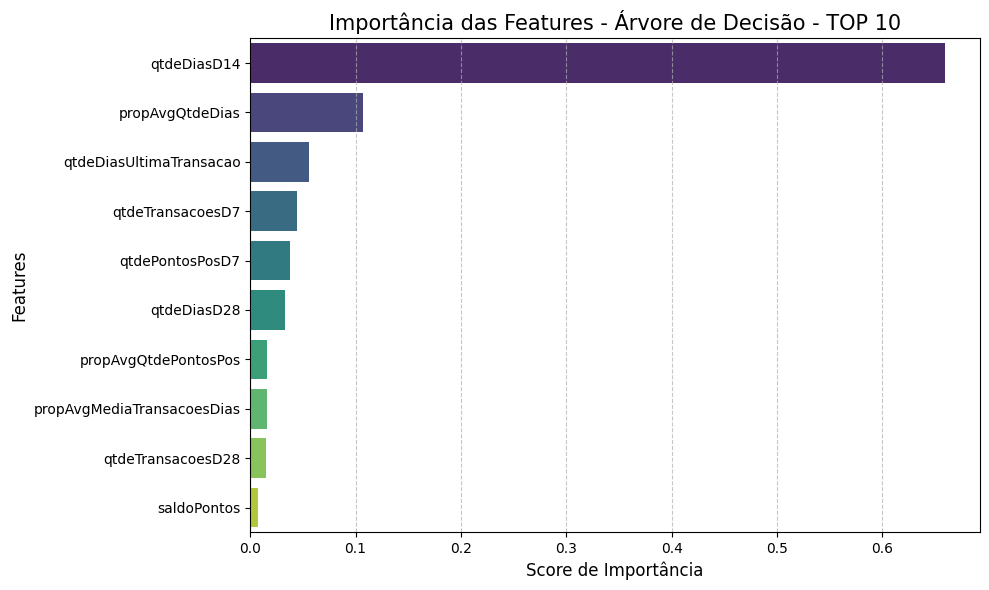

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Selecionando apenas colunas númericas
X_train_numerico = X_train.select_dtypes(include="number")

# Árvore de Decisão rápida para caçar padrões iniciais
arvore_rapida = DecisionTreeClassifier(max_depth=4)
arvore_rapida.fit(X_train_numerico, y_train)



# Extraindo Feature Importance
importancia_features = pd.Series(
    arvore_rapida.feature_importances_, index=X_train_numerico.columns
)

top_10_features = importancia_features.sort_values(ascending=False).head(10)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values,
            y=top_10_features.index,
            hue=top_10_features.index,
            palette="viridis",
            legend=False)

# 3. Estilização
plt.title("Importância das Features - Árvore de Decisão - TOP 10", fontsize=15)
plt.xlabel("Score de Importância", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Claramente há uma grande diferença percebida pela Árvore de Decisão, em relação a importância de cada feature, sendo a "qtdeDias14" considerada de longe, a mais importante. Há outras features que demonstram certa importância como "propAvgQtdeDias" e "qtdeDiasUltimaTransacao".

## 3. M - Modify (Modificação)
Etapa voltada para transformar os dados brutos para facilitar o aprendizado dos algoritmos.
- Discretização (Binning): Escolha variáveis contínuas importantes (ex: dias desde a última transação) e transforme-as em faixas/categorias. Você pode usar árvores de decisão para encontrar os melhores cortes.
- Codificação de Variáveis (Encoding): Como os algoritmos matemáticos
não lidam bem com textos ou classes ordinais não balanceadas, aplique
técnicas como One-Hot Encoding nas variáveis discretizadas ou categóricas.
- Boas Práticas (Opcional, mas recomendado): Tente encapsular essas
etapas de transformação utilizando a classe Pipeline do Scikit-Learn. Isso evitará que você tenha que repetir o código de transformação para as bases de teste e OOT.

In [10]:
X_train[top_10_features.index.tolist()]

,qtdeDiasD14,propAvgQtdeDias,qtdeDiasUltimaTransacao,qtdeTransacoesD7,qtdePontosPosD7,qtdeDiasD28,propAvgQtdePontosPos,propAvgMediaTransacoesDias,qtdeTransacoesD28,saldoPontos
1283,3,0.289318,10.0,0,0,3,0.174560,0.241858,3,150
3015,2,0.482197,6.0,2,51,5,0.299079,0.580460,12,257
3773,1,2.994404,6.0,1,50,5,2.763287,0.386389,13,1969
1823,1,0.165473,7.0,4,53,1,0.109515,0.875096,4,53
4577,0,0.607107,15.0,0,0,1,0.242994,1.145970,1,228
...,...,...,...,...,...,...,...,...,...,...
162,3,1.763257,5.0,4,53,4,1.077548,0.621917,11,626
770,2,0.539178,11.0,0,0,2,0.340563,0.215391,2,100
1089,1,0.269589,3.0,2,51,1,0.173687,0.430781,2,51
4114,10,2.893180,2.0,13,357,19,1.888739,0.427283,38,1623


As variáveis contínuas mais importantes são "propAvgQtdeDias", "propAvgQtdePontosPos" e "propAvgMediaTransacoesDias"

### Pipeline modificador - Discretização (Binning)/ Codificação de Variáveis (Encoding)

In [11]:
from feature_engine.discretisation import DecisionTreeDiscretiser
from feature_engine.encoding import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

variaveis_continuas = ["propAvgQtdeDias", "propAvgQtdePontosPos", "propAvgMediaTransacoesDias"]

discretizador = DecisionTreeDiscretiser(
                  cv=3, 
                  scoring='roc_auc', 
                  variables= variaveis_continuas,
                  regression=False,
                  bin_output='boundaries',
                  precision=2
              )

codificador = OneHotEncoder(variables= variaveis_continuas)

modificador = Pipeline(steps=[
    ('discretizer', discretizador),
    ('encoder', codificador),
    ])

### Visualizando dados transformados

In [12]:
modificador.fit(X_train, y_train)
X_train_transformed = modificador.transform(X_train)

display(X_train.head())
display(X_train_transformed.head())

,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,qtdSkuDistintos,qtdeChatMessage,...,qtdeDiasD28,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg
1283,3,3,1.000000,150,150,0,10.0,12.0,1,0,...,3,150,150,0,0.038607,0.289318,0.241858,0.295608,0.174560,0.0
3015,12,5,2.400000,257,257,0,6.0,25.0,2,7,...,5,257,257,0,0.154430,0.482197,0.580460,0.506474,0.299079,0.0
3773,47,27,1.740741,1969,1969,0,6.0,98.0,4,19,...,5,757,757,0,0.640393,2.994404,0.386389,4.361164,2.763287,0.0
1823,4,1,4.000000,53,53,0,7.0,7.0,2,3,...,1,53,53,0,0.080967,0.165473,0.875096,0.153916,0.109515,0.0
4577,32,7,4.571429,228,228,0,15.0,107.0,2,28,...,1,1,1,0,0.395953,0.607107,1.145970,0.439370,0.242994,0.0


,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,qtdSkuDistintos,qtdeChatMessage,...,"propAvgQtdePontosPos_(0.0021, 0.11]","propAvgQtdePontosPos_(-inf, 0.0021]","propAvgMediaTransacoesDias_(0.214, 0.251]","propAvgMediaTransacoesDias_(0.444, 0.867]","propAvgMediaTransacoesDias_(0.256, 0.444]","propAvgMediaTransacoesDias_(0.867, 5.111]","propAvgMediaTransacoesDias_(5.111, inf]","propAvgMediaTransacoesDias_(0.251, 0.252]","propAvgMediaTransacoesDias_(-inf, 0.214]","propAvgMediaTransacoesDias_(0.252, 0.256]"
1283,3,3,1.000000,150,150,0,10.0,12.0,1,0,...,0,0,1,0,0,0,0,0,0,0
3015,12,5,2.400000,257,257,0,6.0,25.0,2,7,...,0,0,0,1,0,0,0,0,0,0
3773,47,27,1.740741,1969,1969,0,6.0,98.0,4,19,...,0,0,0,0,1,0,0,0,0,0
1823,4,1,4.000000,53,53,0,7.0,7.0,2,3,...,0,0,0,0,0,1,0,0,0,0
4577,32,7,4.571429,228,228,0,15.0,107.0,2,28,...,0,0,0,0,0,1,0,0,0,0


## 4. M - Model (Modelagem)
- Seleção de Algoritmo: Escolha um algoritmo de classificação (ex: Random Forest, Regressão Logística).
- Otimização de Hiperparâmetros Tuning Não utilize o modelo apenas com os parâmetros padrão. Utilize técnicas como GridSearchCV ou RandomizedSearchCV para testar diferentes combinações de parâmetros (ex: profundidade da árvore, número de estimadores).
- Validação Cruzada (Cross-Validation): Durante a otimização, utilize validação cruzada (CV) na base de treino para garantir que os parâmetros escolhidos são robustos.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Encapsulamento: Modify + Model
pipeline_completo = Pipeline([
    ('prep', modificador),
    ('rf', RandomForestClassifier(random_state=42))
])

parametros = {
    'rf__n_estimators': [x for x in range(50, 310, 50)],
    'rf__max_depth': [x for x in range(5, 25, 5)],
}

# Otimização via Cross-Validation (CV=3)
grid = GridSearchCV(
    pipeline_completo, parametros, cv=3, scoring='roc_auc'
)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_depth': [5, 10, ...], 'rf__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also 

## 5. A - Assess (Avaliação/Acesso)
- Métricas de Performance: Calcule a ROC AUC e a Acurácia. Compare os resultados obtidos na base de Treino, na base de Teste e na base Out-of-Time. Analise se houve Overfitting (quando o modelo vai muito bem no treino e mal no teste).
- Análise de Negócio (Lift/Gains): Ordene a base de Teste pela probabilidade de Churn gerada pelo modelo. Crie um gráfico ou tabela mostrando o percentual de churners capturados caso abordássemos apenas os 10%, 20% ou 30% dos usuários com maior risco. Demonstre o ganho que o seu modelo traz em relação a uma escolha aleatória.
- Serialização: Salve o modelo final (e o pipeline de transformações) em um arquivo (ex: .pkl via biblioteca pickle ) ou utilize o MLFlow para registrar o seu modelo, simulando a entrega de um artefato para produção.

### Métricas de performance

In [53]:
import pickle
from sklearn.metrics import roc_auc_score, accuracy_score

y_prob_treino = grid.predict_proba(X_train)[:, 1]
y_prob_teste = grid.predict_proba(X_test)[:, 1]
y_prob_oot = grid.predict_proba(df_oot.drop(columns=['flagChurn']))[:, 1]

y_pred_treino = grid.predict(X_train)
y_pred_teste = grid.predict(X_test)
y_pred_oot = grid.predict(df_oot.drop(columns=['flagChurn']))

print(f'ROC AUC Treino: {roc_auc_score(y_train, y_prob_treino):.4f}')
print(f'ROC AUC Teste: {roc_auc_score(y_test, y_prob_teste):.4f}')
print(f'ROC AUC OOT: {roc_auc_score(df_oot["flagChurn"], y_prob_oot):.4f}')

print(f'Accuracy Treino: {accuracy_score(y_train, y_pred_treino):.4f}')
print(f'Accuracy Teste: {accuracy_score(y_test, y_pred_teste):.4f}')
print(f'Accuracy OOT: {accuracy_score(df_oot["flagChurn"], y_pred_oot):.4f}')

ROC AUC Treino: 0.8396
ROC AUC Teste: 0.8288
ROC AUC OOT: 0.8405
Accuracy Treino: 0.7559
Accuracy Teste: 0.7575
Accuracy OOT: 0.7789


O modelo não apresenta overfitting devido à baixa variância entre os resultados de Treino, Teste e OOT, indicando que o algoritmo capturou padrões estatísticos generalizáveis e não ruídos específicos da base de treinamento, garantindo previsões confiáveis em dados futuros.

### Análise de Negócio (Lift/Gains)

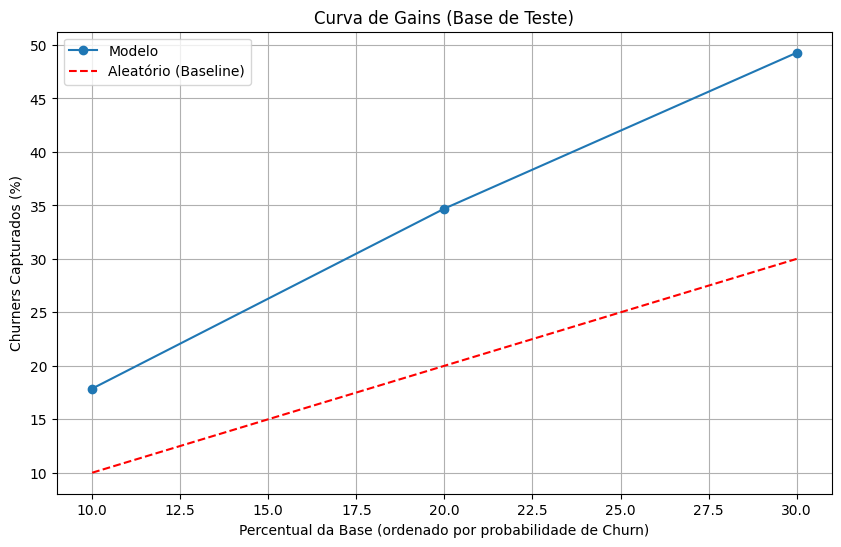

,Percentual da Base,Churners Capturados (%),Baseline (%),Lift
0,10,17.86,10.0,1.79
1,20,34.70,20.0,1.74
2,30,49.28,30.0,1.64


In [50]:
import numpy as np
import matplotlib.pyplot as plt

df_results = pd.DataFrame({'true_churn': y_test, 'churn_proba': y_prob_teste})

df_results = df_results.sort_values(by='churn_proba', ascending=False).reset_index(drop=True)

total_churners = df_results['true_churn'].sum()

percentiles = np.arange(0.1, 0.31, 0.1)
cumulative_churners = []

for p in percentiles:
    n_customers = int(len(df_results) * p)
    churners_in_segment = df_results.head(n_customers)['true_churn'].sum()
    cumulative_churners.append(churners_in_segment)

churners_captured_pct = (np.array(cumulative_churners) / total_churners) * 100

baseline_churn_rate = total_churners / len(df_results)
random_capture_pct = (percentiles * total_churners / total_churners) * 100

df_gains = pd.DataFrame({
    'Percentual da Base': (percentiles * 100).astype(int),
    'Churners Capturados (%)': churners_captured_pct,
    'Baseline (%)': random_capture_pct,
    'Lift': churners_captured_pct/random_capture_pct
})

plt.figure(figsize=(10, 6))
plt.plot(df_gains['Percentual da Base'], df_gains['Churners Capturados (%)'], marker='o', label='Modelo')
plt.plot(df_gains['Percentual da Base'], df_gains['Baseline (%)'], linestyle='--', color='red', label='Aleatório (Baseline)')
plt.title('Curva de Gains (Base de Teste)')
plt.xlabel('Percentual da Base (ordenado por probabilidade de Churn)')
plt.ylabel('Churners Capturados (%)')
plt.grid(True)
plt.legend()
plt.show()

display(df_gains.round(2))

- Eficiência de Foco: "Se focarmos nossos esforços de retenção em apenas 30% da base (os de maior risco), conseguiremos capturar quase metade (49.28%) de todos os clientes que cancelariam."

- Superioridade do Modelo: "Nos 10% de maior risco, o modelo é 1.79 vezes (79%) mais eficiente que uma campanha disparada aleatoriamente."

- Economia de Recursos: "Isso permite que o time de marketing ou CS economize orçamento, deixando de oferecer descontos para quem não tem risco de sair e focando onde o problema realmente está."

### Serialização

In [52]:
# Salvando o modelo final
with open('modelo_churn.pkl', 'wb') as file:
    pickle.dump(grid.best_estimator_, file)